In [1]:
import pandas as pd
df_1 = pd.read_csv('prune_train.csv')
df_2 = pd.read_csv('prune_test.csv')
x_train = df_1.drop(['NO(%)'],axis=1)
x_test = df_2.drop(['NO(%)'],axis=1)
y_train = df_1['NO(%)']
y_test = df_2['NO(%)']

In [2]:
from catboost import CatBoostRegressor
catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,verbose=False)

In [3]:
import numpy as np
from sklearn.utils import resample
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def bootstrap_predict_ci(
    model, X_train, y_train, X_val, y_val=None,
    n_boot=1000, alpha=0.05, random_state=None,
    return_dict=True
):
    """
    Bootstrap 预测区间 + 性能指标分布（MAE / RMSE / R² / MRE）
    """

    rng = np.random.RandomState(random_state)
    preds = []

    mae_list = []
    rmse_list = []
    r2_list = []
    mre_list = []   # ✅ 新增

    y_val_arr = None
    if y_val is not None:
        y_val_arr = np.asarray(y_val).ravel()

        # ✅ 自适应 eps（避免除0 & 小值爆炸）
        eps = 1e-6 * np.mean(np.abs(y_val_arr))

    for _ in range(n_boot):
        # 1) bootstrap 采样训练集
        X_bs, y_bs = resample(
            X_train, y_train,
            replace=True,
            random_state=rng.randint(0, 1_000_000)
        )

        # 2) 克隆模型
        model_bs = clone(model)

        # 3) 训练
        model_bs.fit(X_bs, y_bs)

        # 4) 预测
        y_pred = np.asarray(model_bs.predict(X_val)).ravel()
        preds.append(y_pred)

        # 5) 指标计算
        if y_val_arr is not None:
            mae_list.append(mean_absolute_error(y_val_arr, y_pred))
            rmse_list.append(np.sqrt(mean_squared_error(y_val_arr, y_pred)))
            r2_list.append(r2_score(y_val_arr, y_pred))

            # ===== ✅ MRE =====
            rel_error = np.abs((y_val_arr - y_pred) / (y_val_arr + eps))
            mre_list.append(np.mean(rel_error))

    preds = np.asarray(preds)

    # ===== 预测CI =====
    mean_pred = preds.mean(axis=0)
    lower = np.percentile(preds, 100 * (alpha / 2), axis=0)
    upper = np.percentile(preds, 100 * (1 - alpha / 2), axis=0)
    ci_width = upper - lower

    print("平均CI宽度:", np.mean(ci_width))

    if not return_dict:
        return mean_pred, lower, upper, preds

    results = {
        "mean_pred": mean_pred,
        "lower": lower,
        "upper": upper,
        "preds": preds,
        "ci_width": ci_width
    }

    # ===== 指标统计 =====
    if y_val_arr is not None:
        mae_arr = np.asarray(mae_list)
        rmse_arr = np.asarray(rmse_list)
        r2_arr = np.asarray(r2_list)
        mre_arr = np.asarray(mre_list)  # ✅ 新增

        def _summary(arr):
            return {
                "mean": float(np.mean(arr)),
                "std": float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
                "ci_low": float(np.percentile(arr, 100 * (alpha / 2))),
                "ci_high": float(np.percentile(arr, 100 * (1 - alpha / 2)))
            }

        results.update({
            "mae": mae_arr,
            "rmse": rmse_arr,
            "r2": r2_arr,
            "mre": mre_arr,  # ✅ 新增
            "summary": {
                "mae": _summary(mae_arr),
                "rmse": _summary(rmse_arr),
                "r2": _summary(r2_arr),
                "mre": _summary(mre_arr)  # ✅ 新增
            }
        })

        # ===== 打印 =====
        print(f"MAE 均值: {results['summary']['mae']['mean']:.4f} ± {results['summary']['mae']['std']:.4f}")
        print(f"RMSE 均值: {results['summary']['rmse']['mean']:.4f} ± {results['summary']['rmse']['std']:.4f}")
        print(f"R² 均值: {results['summary']['r2']['mean']:.4f} ± {results['summary']['r2']['std']:.4f}")
        print(f"MRE 均值: {results['summary']['mre']['mean']:.4f} ± {results['summary']['mre']['std']:.4f}")

        print(f"MAE 95% CI: ({results['summary']['mae']['ci_low']:.4f}, {results['summary']['mae']['ci_high']:.4f})")
        print(f"RMSE 95% CI: ({results['summary']['rmse']['ci_low']:.4f}, {results['summary']['rmse']['ci_high']:.4f})")
        print(f"R² 95% CI: ({results['summary']['r2']['ci_low']:.4f}, {results['summary']['r2']['ci_high']:.4f})")
        print(f"MRE 95% CI: ({results['summary']['mre']['ci_low']:.4f}, {results['summary']['mre']['ci_high']:.4f})")

    return results

In [4]:
results = bootstrap_predict_ci(
    model=catboost,
    X_train=x_train,
    y_train=y_train,
    X_val=x_test,
    y_val=y_test,
    n_boot=1000,
    alpha=0.05,
    random_state=42
)


平均CI宽度: 19.96676215586343
MAE 均值: 6.0051 ± 0.8094
RMSE 均值: 8.2671 ± 1.2290
R² 均值: 0.7399 ± 0.0788
MRE 均值: 0.1645 ± 0.0225
MAE 95% CI: (4.5995, 7.7964)
RMSE 95% CI: (6.2379, 10.9613)
R² 95% CI: (0.5525, 0.8551)
MRE 95% CI: (0.1274, 0.2141)


In [11]:
results = bootstrap_predict_ci(
    model=catboost,
    X_train=x_train,
    y_train=y_train,
    X_val=x_test,
    y_val=y_test,
    n_boot=18,
    alpha=0.05,
    random_state=42
)


平均CI宽度: 17.064811701298932
MAE 均值: 6.0894 ± 0.6955
RMSE 均值: 8.3705 ± 1.0551
R² 均值: 0.7352 ± 0.0649
MRE 均值: 0.1728 ± 0.0224
MAE 95% CI: (4.9140, 7.0379)
RMSE 95% CI: (6.4084, 10.0818)
R² 95% CI: (0.6211, 0.8469)
MRE 95% CI: (0.1416, 0.2176)


In [4]:
from matplotlib import pyplot as plt
import seaborn as sns
import os 
def draw_scatter(train_true, train_pred, test_true, test_pred, title,
                  actual_text='actual', pred_text='prediction',save=False):

    # 统一字体设置
    plt.rcParams['font.family'] = 'Times New Roman'
    # plt.rcParams['font.sans-serif'] = ['Arial']  # 备用字体

    # 设置整张图背景颜色
    '''
    1、创建Figure时直接设置
    plt.figure(facecolor='w'))
    
    2、对现有的Figure设置
    plt.gcf()  #获取当前的图
    fig.set_facecolor('white')
    '''
    #设置的是整个图的颜色
    #plt.figure(facecolor='lightgrey')  #还可以使用RGB元组(0.8,0.8,0.8)取值范围0~1

    # 定义字体样式
    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',  # 深灰色
        'weight': 'bold',
        'size': 18
    }

    # 绘制散点图
    sns.regplot(x=test_true, y=test_pred, color="orange", label="test")
    sns.regplot(x=train_true, y=train_pred, color="dodgerblue", label="train")

    # 设置坐标轴标签和范围
    plt.xlabel(actual_text, fontdict=font_common,weight='bold')
    plt.ylabel(pred_text, fontdict=font_common,weight='bold')
    plt.xlim(0, 100)
    plt.ylim(0, 100)

    # 设置图例
    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}
    plt.legend(loc="upper right", markerscale=1.5, prop=legend_font,frameon=True, bbox_to_anchor=(0.3, 1))
    '''
    frameon:设置图例是否具有边框，bbox_to_anchor调整图例位置
    loc:控制图例在绘图区内的基准位置，可以配合bbox_to_anchor使用
    loc:    best   0自动化选择最好位置
            upper right 右上角1
            upper left  左上角2
            lower left  左下3
            lower right 右下4
            right  垂直居中 右侧5            center left 左侧垂直居中6
    '''


    #获取图中绘制的图
    ax = plt.gca()

    # 设置主刻度线 - 更明显的显示
    ax.tick_params(
        axis='both',          # 同时设置x轴和y轴
        which='major',        # 主刻度线
        direction='out',       # 刻度线方向：向内
        length=8,            # 增加刻度线长度
        width=2,             # 增加刻度线宽度
        color='black',       # 刻度线颜色
        labelsize=14,        # 标签大小
        bottom=True,         # 显示底部刻度线
        left=True,           # 显示左侧刻度线
        top=False,            # 显示顶部刻度线
        right=False           # 显示右侧刻度线
    )
    #设置颜色
    ax.set_facecolor('white')

    #设置边框
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

    #设置图内网格
    plt.grid(True,
             axis='both',
             linestyle='--',
             linewidth=0.5,
             color='gray',
             alpha=0.6)

    # 添加统计信息文本
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(train_true.values.ravel() / 100, train_pred / 100)
    _, test_rmse, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(test_true.values.ravel() / 100, test_pred / 100)

    plt.text(60, 26, f"Train R² = {(int(train_r2*1000)/1000):.3f}", **font_common)
    plt.text(60, 18, f"Test R² = {test_r2:.3f}", **font_common)
    plt.text(60, 10, f"RMSE = {test_rmse:.3f}", **font_common)

    # 添加标题
    plt.text(50, 90, title, **font_common, horizontalalignment="center")

    # 保存图像
    if save:
        out_put = 'scatter_images'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"测试图已保存：{output_path}")

In [5]:
from prepare import process_regressor, model_performance_metrics,draw_scatter

cv train R2: 0.021 (+/- 0.107) 

Catboost Train mse: 0.00008 | rmse: 0.00891 | mae: 0.00707 | mape: 1.73830 | smape: 1.72872 | r2: 0.99772

Catboost Test mse: 0.00160 | rmse: 0.03998 | mae: 0.02833 | mape: 7.97064 | smape: 7.53744 | r2: 0.94048

测试图已保存：scatter_images\prune CatBoost.jpg


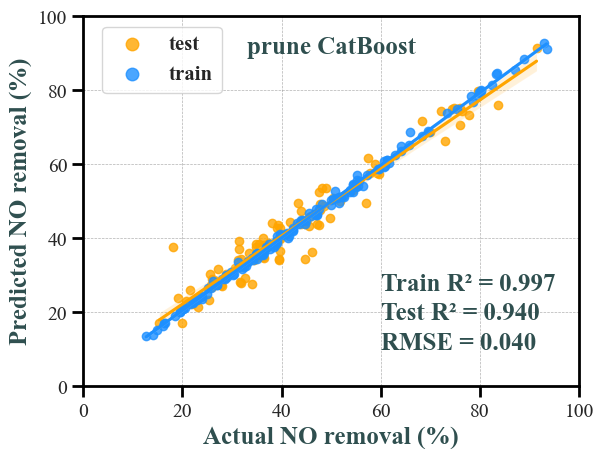

In [6]:
catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,verbose=False)
model = catboost.fit(x_train, y_train)

train_pred, test_pred = process_regressor(catboost, x_train, x_test, y_train, y_test)
model_performance_metrics('Catboost Train', y_train, train_pred)
model_performance_metrics('Catboost Test', y_test, test_pred)
draw_scatter(y_train, train_pred, y_test, test_pred, "prune CatBoost", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)

In [49]:
model

In [50]:
pd.set_option('display.max_rows', None)     # 显示所有行
pd.set_option('display.max_columns', None)  # 显示所有列

In [7]:
catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,verbose=False)
model = catboost.fit(x_train, y_train)
y_new = y_test
y_pred = model.predict(x_test)
df_compare = pd.DataFrame({
    "Actual": y_new,
    "Predicted": y_pred,
    "Error": y_pred - y_new
})

print(df_compare)

    Actual  Predicted     Error
0    91.40  91.294904 -0.105096
1    31.90  27.890866 -4.009134
2    27.69  27.275311 -0.414689
3    32.61  29.305588 -3.304412
4    39.72  36.517665 -3.202335
..     ...        ...       ...
92   20.80  23.041554  2.241554
93   21.60  26.026459  4.426459
94   34.80  38.437891  3.637891
95   58.83  60.108171  1.278171
96   43.40  49.611238  6.211238

[97 rows x 3 columns]


In [8]:
a = pd.read_csv('test.csv')

In [9]:
x = a.drop('NO(%)', axis=1)
y = a['NO(%)']

In [10]:
x

,Urea,Melamine,Dcda,PM(g),Time(h),Heat(℃),HR(℃/min),hata,modefiy,dope,...,area(cm2),NO(ppm),rate(mL/min),Xe,Wu,LED,Intensity(W),BET(m2/g),Eg(eV),NO2(%)
0,1,0,0,10.0,0.00,550,15.0,0,0,0,...,80.0,0.6,2400,0,1,0,150,31.000000,2.72,15.450000
1,1,0,0,10.0,0.25,550,15.0,0,0,0,...,80.0,0.6,2400,0,1,0,150,35.000000,2.70,14.560000
2,1,0,0,10.0,0.50,550,15.0,0,0,0,...,80.0,0.6,2400,0,1,0,150,52.000000,2.69,14.170000
3,1,0,0,10.0,1.00,550,15.0,0,0,0,...,80.0,0.6,2400,0,1,0,150,62.000000,2.68,13.670000
4,1,0,0,10.0,2.00,550,15.0,0,0,0,...,80.0,0.6,2400,0,1,0,150,75.000000,2.72,12.520000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,0,1,0,10.0,2.00,550,5.0,0,0,1,...,80.0,0.6,2400,1,0,0,150,35.400000,2.60,15.033759
251,1,0,0,15.0,1.00,550,15.0,0,0,0,...,80.0,0.6,2000,1,0,0,300,46.287646,2.86,39.400000
252,1,0,0,15.0,1.00,550,15.0,0,0,1,...,80.0,0.6,2000,1,0,0,300,47.196260,2.12,17.500000
253,0,1,0,10.0,4.00,550,10.0,0,0,0,...,80.0,0.6,2000,1,0,0,300,34.800000,3.00,8.800000


In [11]:
y

0      26.0
1      28.5
2      29.7
3      30.3
4      31.3
       ... 
250    55.4
251    20.2
252    39.6
253    22.0
254    36.0
Name: NO(%), Length: 255, dtype: float64

In [12]:
y_pred = model.predict(x)
df_compare = pd.DataFrame({
    "Actual": y,
    "Predicted": y_pred,
    "Error": y - y_pred
})

df_compare

,Actual,Predicted,Error
0,26.0,30.721652,-4.721652
1,28.5,35.453852,-6.953852
2,29.7,34.398200,-4.698200
3,30.3,34.990290,-4.690290
4,31.3,35.993020,-4.693020
...,...,...,...
250,55.4,43.812542,11.587458
251,20.2,24.372622,-4.172622
252,39.6,43.674724,-4.074724
253,22.0,29.353502,-7.353502


In [ ]:
    df_a = df.loc[remove_a[i]]
    X_train_val = df_a.drop(columns=['NO(%)'])
    y_train_val = df_a['NO(%)']

    df_a_val = df.loc[a_dict[i]]
    X_val = df_a_val.drop(columns=['NO(%)'])
    y_val = df_a_val['NO(%)']

    train_pred, val_pred = process_regressor(model[a],X_train_val,X_val,y_train_val,y_val,cv=False)
    _,test_pred = process_regressor(model[a],X_train_val,X_test,y_train_val,y_test,cv=False)

In [13]:
from catboost import CatBoostRegressor
model = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,
                                 depth=5,iterations = 900,verbose=False)

In [14]:
from prepare import get_mse_rmse_mae_mape_smape_r2
import os
from matplotlib import pyplot as plt
import seaborn as sns
def draw_scatter_1(train_true, train_pred, val_true, val_pred, test_true, test_pred, title,
                  actual_text='actual', pred_text='prediction', save=False):
    """
    绘制三组数据的散点图（训练集、验证集、测试集）
    
    Parameters:
    -----------
    train_true, train_pred: 训练集真实值和预测值
    val_true, val_pred: 验证集真实值和预测值  
    test_true, test_pred: 测试集真实值和预测值
    title: 图表标题
    actual_text: x轴标签文本
    pred_text: y轴标签文本
    save: 是否保存图片
    """
    
    # 统一字体设置
    plt.rcParams['font.family'] = 'Times New Roman'
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 定义字体样式
    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',
        'weight': 'bold',
        'size': 18
    }
    
    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}

    # 绘制散点图
    sns.regplot(x=train_true, y=train_pred,
                color="dodgerblue", label='train',
                scatter_kws={'alpha': 0.5, 's': 18},
                ax=ax)
    sns.regplot(x=test_true, y=test_pred, color='#FF69B4', label='test',
                scatter_kws={'alpha': 0.8, 's': 30},
                ax=ax)
    sns.regplot(x=val_true, y=val_pred,
                color="orange", label="val",
                scatter_kws={'alpha': 0.5, 's': 10},
                ax=ax)

    # 设置坐标轴标签和范围
    ax.set_xlabel(actual_text, fontdict=font_common, weight='bold')
    ax.set_ylabel(pred_text, fontdict=font_common, weight='bold')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

    # 设置图例
    ax.legend(loc="upper right", markerscale=1.5, prop=legend_font, 
              frameon=True, bbox_to_anchor=(0.3, 0.85))

    # 设置刻度 - 优化部分
    ax.tick_params(axis='both', which='major', direction='out', 
                   width=2, labelsize=14,
                   bottom=True, top=False, left=True, right=False)  # 只显示下轴和左轴的主刻度
    
    # 设置次刻度（可选，如果需要更精细的刻度）
    ax.tick_params(axis='both', which='minor', direction='out',
                   bottom=True, top=False, left=True, right=False)
    
    # 设置主刻度间隔
    ax.xaxis.set_major_locator(plt.MultipleLocator(20))  # x轴每20一个主刻度
    ax.yaxis.set_major_locator(plt.MultipleLocator(20))  # y轴每20一个主刻度
    
    # 设置次刻度间隔（可选）
    ax.xaxis.set_minor_locator(plt.MultipleLocator(10))  # x轴每10一个次刻度
    ax.yaxis.set_minor_locator(plt.MultipleLocator(10))  # y轴每10一个次刻度

    # 设置图形样式
    ax.set_facecolor('white')
    
    # 设置边框
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

    # 设置网格
    ax.grid(True, axis='both', linestyle='--', 
            linewidth=0.5, color='gray', alpha=0.6)

    # 添加统计信息文本
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(
        train_true.values.ravel() / 100, train_pred / 100)
    _, _, _, _, _, val_r2 = get_mse_rmse_mae_mape_smape_r2(
        val_true.values.ravel() / 100, val_pred / 100)
    _, _, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(
        test_true.values.ravel() / 100, test_pred / 100)

    ax.text(60, 26, f"Train R² = {train_r2:.3f}", **font_common)
    ax.text(60, 18, f"val   R² = {val_r2:.3f}", **font_common)
    ax.text(60, 10, f"test  R² = {test_r2:.3f}", **font_common)

    # 添加标题
    ax.text(50, 90, title, **font_common, horizontalalignment="center")

    # 保存图像
    if save:
        out_put = 'scatter_images'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"测试图已保存：{output_path}")

    plt.tight_layout()
    plt.show()

In [15]:
df_2 = pd.read_csv('test.csv')
x_test = df_2.drop(['NO(%)'],axis=1)
y_test = df_2['NO(%)']
catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,verbose=False)
model = catboost.fit(x_train, y_train)
y_new = y_test
y_pred = model.predict(x_test)
df_compare = pd.DataFrame({
    "Actual": y_new,
    "Predicted": y_pred,
    "Error": y_pred - y_new
})

print(df_compare)

     Actual  Predicted      Error
0      26.0  30.721652   4.721652
1      28.5  35.453852   6.953852
2      29.7  34.398200   4.698200
3      30.3  34.990290   4.690290
4      31.3  35.993020   4.693020
..      ...        ...        ...
250    55.4  43.812542 -11.587458
251    20.2  24.372622   4.172622
252    39.6  43.674724   4.074724
253    22.0  29.353502   7.353502
254    36.0  42.221591   6.221591

[255 rows x 3 columns]


In [16]:
a = [0,2,5,12,20,21,22,24,25,31,28,33,34,35,39,42,74,173,175,176,179,239,240,154,192,201,216,217,221,239]
selected_rows = df_2.iloc[a]

x_test = selected_rows.drop(['NO(%)'],axis=1)
y_test = selected_rows['NO(%)']
catboost = CatBoostRegressor(l2_leaf_reg= 3,learning_rate=0.05,depth=5,iterations = 900,verbose=False)
model = catboost.fit(x_train, y_train)
y_new = y_test
y_pred = model.predict(x_test)
df_compare = pd.DataFrame({
    "Actual": y_new,
    "Predicted": y_pred,
    "Error": y_pred - y_new
})

print(df_compare)

     Actual  Predicted      Error
0      26.0  30.721652   4.721652
2      29.7  34.398200   4.698200
5      32.1  35.777097   3.677097
12     32.7  32.220099  -0.479901
20     40.7  40.960486   0.260486
21     39.6  40.890377   1.290377
22     22.0  24.848251   2.848251
24     39.3  35.103256  -4.196744
25     26.8  23.944694  -2.855306
31     33.5  32.600343  -0.899657
28     47.6  42.437531  -5.162469
33     37.7  38.316248   0.616248
34     42.3  39.106715  -3.193285
35     37.5  40.069929   2.569929
39     54.2  47.363943  -6.836057
42     42.3  40.743987  -1.556013
74     41.0  40.699280  -0.300720
173    65.0  53.174960 -11.825040
175    57.0  52.615794  -4.384206
176    35.6  38.489047   2.889047
179    60.8  55.801629  -4.998371
239    45.4  43.817557  -1.582443
240    54.5  47.439642  -7.060358
154    57.0  61.290266   4.290266
192    32.6  34.773480   2.173480
201    32.8  32.065420  -0.734580
216    37.0  37.177263   0.177263
217    57.0  50.089279  -6.910721
221    34.9  3

In [17]:
import pandas as pd
from prepare import process_regressor
df_1 = pd.read_csv('prune_train.csv')
df = pd.read_csv('prune_test.csv')
df_2 = pd.read_csv('new_test.csv')
x_train = df_1.drop(['NO(%)'],axis=1)
x_val = df.drop(columns=['NO(%)'])
x_test = selected_rows.drop(['NO(%)'],axis=1)
y_train = df_1['NO(%)']
y_val = df['NO(%)']
y_test = selected_rows['NO(%)']

In [20]:
train_pred, val_pred = process_regressor(model,x_train,x_val,y_train,y_val,cv=False)
_,test_pred = process_regressor(model,x_train,x_test,y_train,y_test,cv=False)
process_regressor(model,x_train,x_test,y_train,y_test,cv=False)
model_performance_metrics('Cat Train', y_train, train_pred)
model_performance_metrics('Cat Test', y_test, test_pred)

Cat Train mse: 0.00008 | rmse: 0.00891 | mae: 0.00707 | mape: 1.73830 | smape: 1.72872 | r2: 0.99772

Cat Test mse: 0.00170 | rmse: 0.04117 | mae: 0.03209 | mape: 7.57270 | smape: 7.64357 | r2: 0.85644



0.8564426040642046

测试图已保存：scatter_images\Catboost prune.jpg


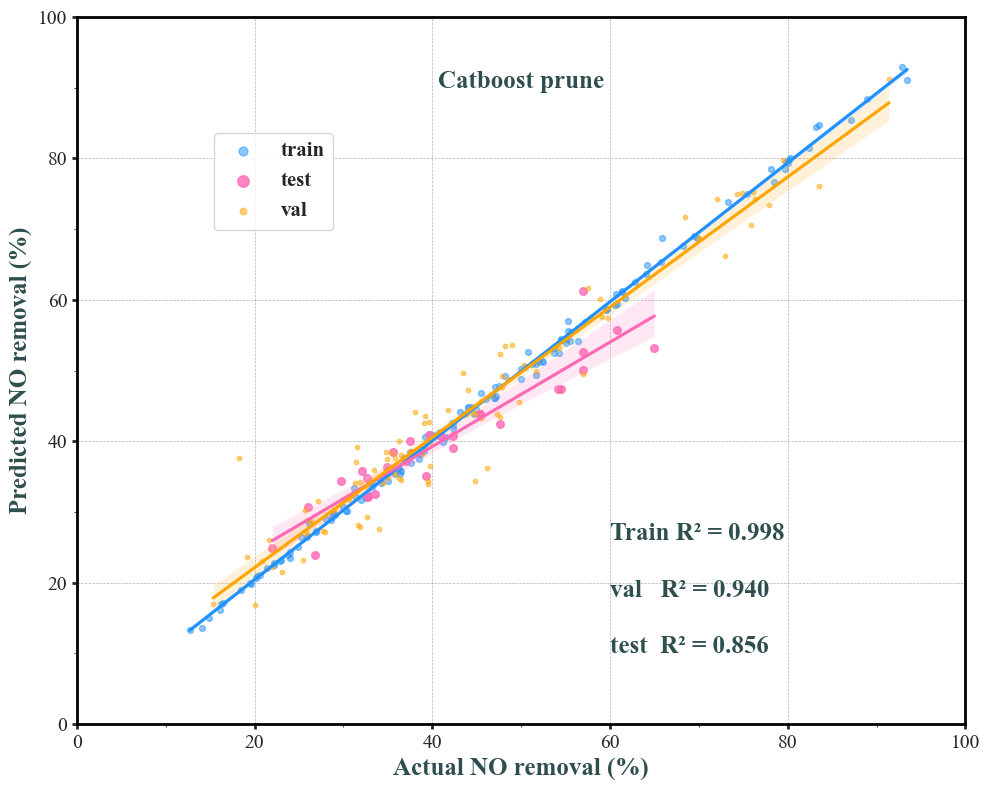

In [57]:
draw_scatter_1(y_train, train_pred, y_val,val_pred,y_test, test_pred, "Catboost prune", actual_text='Actual NO removal (%)',pred_text='Predicted NO removal (%)',save=True)